In [1]:
import numpy as np
import pandas as pd
import glob, os, vcf, warnings, shutil, subprocess, re
from Bio import Seq, SeqIO
from Bio.Data import CodonTable
import sys
sys.path.append("../variantDetector")
from utils import *

warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import scipy, pysam
from matplotlib.colors import ListedColormap
from collections import Counter
from dna_features_viewer import GraphicFeature, GraphicRecord

h37Rv_path = "/n/data1/hms/dbmi/farhat/Sanjana/H37Rv"
h37Rv_seq = SeqIO.read(os.path.join(h37Rv_path, "GCF_000195955.2_ASM19595v2_genomic.gbff"), "genbank")
h37Rv_genes = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_genes_v4.csv"))
h37Rv_regions = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_v4.csv"))

h37Rv_coords = pd.read_csv(os.path.join(h37Rv_path, "h37Rv_coords_to_gene.csv"))
h37Rv_coords_dict = dict(zip(h37Rv_coords["pos"].values, h37Rv_coords["region"].values))

# remove rRNAs, which are highly conserved. rrs, rrl, and rrf
rRNA_pos = []

for i, row in h37Rv_regions.query("Functional_Category=='stable RNAs' & Feature=='rRNA'").iterrows():
    # print(row['Name'])
    rRNA_pos += list(np.arange(row['Start'], row['Stop'] + 1))

TRUST_data_dir = "~/TRUST_data_processing/processed_data"
df_trust_patients = pd.read_csv(f"{TRUST_data_dir}/combined_patient_WGS_data.csv").dropna(subset='Lineage')

isolate_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")
isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/isolate_variants_WHO_catalog.csv")

for i, row in df_trust_patients.iterrows():
    if not row['Original_ID'].startswith('S'):
        
        length_numerical = len(row['Original_ID'].split('-')[0])
            
        newID = 'S' + '0' * (4 - length_numerical) + row['Original_ID']
        df_trust_patients.loc[i, 'Original_ID'] = newID

personal_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly"
H37Rv_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"

mixed_samples = df_trust_patients.query("F2 > 0.03").SampleID.unique()

def get_RvID_from_gff(attr_str):
    """
    Parse the attributes column of a GFF line.
    Returns a dict of key:value pairs.
    """
    attributes = {}
    for item in attr_str.strip().split(";"):
        if item:
            key, value = item.strip().split("=", 1)
            attributes[key] = value

    return attributes['ID'].split('-')[-1]


def get_geneName_from_gff(attr_str):

    attributes = {}
    for item in attr_str.strip().split(";"):
        if item:
            key, value = item.strip().split("=", 1)
            attributes[key] = value

    return attributes['Name']

F2_max = 0.03

clonal_samples = df_trust_patients.query("F2 <= @F2_max").SampleID.unique()

df_who_variants = pd.read_csv(f"~/MtbQuantCNN/data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
genes_with_awR_mutations = df_who_variants.loc[df_who_variants['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')].gene.unique()

cc_df = pd.read_csv(f"~/MtbQuantCNN/data_processing/data_utils/drug_CC.csv")

exclude_regions = pd.read_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/references/BED_files/exclude_regions_50bp.EBRlessThan95Percent.bed", sep='\t', header=None)
high_homology_regions = pd.read_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/references/BED_files/10_high_homology_regions.bed", sep='\t', header=None)
exclude_low_quality_unfixed_SNV_sites = pd.read_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/references/BED_files/exclude_unfixed_SNV_sites.bed", sep='\t', header=None)

exclude_sites = []

for i, row in exclude_regions.iterrows():
    exclude_sites += list(np.arange(row[1], row[2]))
    
for i, row in high_homology_regions.iterrows():
    exclude_sites += list(np.arange(row[1], row[2]))
    
for i, row in exclude_low_quality_unfixed_SNV_sites.iterrows():
    exclude_sites += list(np.arange(row[1], row[2]))
    
exclude_sites = np.unique(exclude_sites)
print(len(exclude_sites) / len(h37Rv_seq.seq))

insertion_seqs_phages_pos = []

for i, row in h37Rv_regions.query("Functional_Category=='insertion seqs and phages'").iterrows():
    insertion_seqs_phages_pos += list(np.arange(row['Start'], row['Stop'] + 1))
    
insertion_seqs_phages_pos = np.unique(insertion_seqs_phages_pos)

0.09069094364497413


In [3]:
df_trust_patients.query("SampleID in ['MFS-696', 'MFS-663', 'MFS-127', 'MFS-145', 'MFS-796', 'MFS-800']")[['SampleID', 'F2']]

,SampleID,F2
191,MFS-796,0.009803
198,MFS-800,0.005866
214,MFS-696,0.108637
425,MFS-663,0.011089
742,MFS-127,0.013948
747,MFS-145,0.122113


# Pilon Candidate Variants from H37Rv Alns

In [2]:
SNP_data_files = glob.glob(f"{H37Rv_ref_dir}/*/pilon/lowAF_SNVs_aln_stats.csv")

df_candidate_SNPs = []

for fName in SNP_data_files:

    match = re.search(r'MFS-\d{1,3}', fName)

    df = pd.read_csv(fName).query("REF.str.len() == ALT.str.len()")        
    df['SampleID'] = match.group()
    df_candidate_SNPs.append(df)

df_candidate_SNPs = pd.concat(df_candidate_SNPs).query("DP >= 5")

ground_truth_SNP_data_files = glob.glob(f"{personal_ref_dir}/*/pilon/ground_truth.csv")
samples_with_ground_truth = os.listdir(personal_ref_dir)

df_ground_truth = []

for fName in ground_truth_SNP_data_files:

    match = re.search(r'MFS-\d{1,3}', fName)

    df = pd.read_csv(fName).query("REF.str.len() == ALT.str.len()").query("POS not in @rRNA_pos & POS not in @insertion_seqs_phages_pos")
    df['SampleID'] = match.group()
    df_ground_truth.append(df)

df_ground_truth = pd.concat(df_ground_truth).merge(df_trust_patients[['pid', 'SampleID', 'Coll2014', 'Freschi2020', 'Lineage', 'F2']], on='SampleID', how='left').query("F2 <= @F2_max")

assert sum(pd.isnull(df_ground_truth['pid'])) == 0
df_ground_truth['Real'] = 1

# remove rRNA pos, which have too many false positives due to contamination
df_candidate_SNPs = df_candidate_SNPs.query("POS not in @rRNA_pos & POS not in @insertion_seqs_phages_pos")

# weird characters in the columns
df_candidate_SNPs.rename(columns={'ANN[0].GENE': 'GENE', 'ANN[0].HGVS_C': 'HGVS_C', 'ANN[0].HGVS_P': 'HGVS_P'}, inplace=True)

# add pid
df_candidate_SNPs = df_candidate_SNPs.merge(df_trust_patients[['pid', 'SampleID', 'Coll2014', 'Freschi2020', 'Lineage', 'F2']], on='SampleID', how='left').query("F2 <= @F2_max")

assert sum(pd.isnull(df_candidate_SNPs['pid'])) == 0
# df_candidate_SNPs['Lineage'] = df_candidate_SNPs['Lineage'].astype(int)

print(f"{df_candidate_SNPs.SampleID.nunique()} WGS samples across {df_candidate_SNPs.pid.nunique()} pids")

732 WGS samples across 417 pids


In [15]:
df_freebayes_SNVs = pd.concat([pd.read_csv("../variantDetector/unmixed_only/training_data.csv"), 
                               pd.read_csv("../variantDetector/unmixed_only/validation_data.csv")
                              ])

len(df_freebayes_SNVs)

4307

In [27]:
df_compare = df_candidate_SNPs[['SampleID', 'POS']].rename(columns={'POS': 'pilon_POS'}).merge(df_freebayes_SNVs[['SampleID', 'POS']].rename(columns={'POS': 'freebayes_POS'}), how='outer', left_on=['SampleID', 'pilon_POS'], right_on=['SampleID', 'freebayes_POS'])

In [31]:
df_compare.loc[pd.isnull(df_compare['pilon_POS'])].query("freebayes_POS not in [3851887, 3851888]")

,SampleID,pilon_POS,freebayes_POS
5052,MFS-106,NaN,1271358.0
5053,MFS-106,NaN,3480374.0
5060,MFS-120,NaN,163705.0
5061,MFS-120,NaN,163706.0
5064,MFS-121,NaN,163705.0
...,...,...,...
6638,MFS-95,NaN,483292.0
6639,MFS-96,NaN,483292.0
6640,MFS-96,NaN,1843570.0
6641,MFS-98,NaN,1843570.0


In [30]:
df_compare.loc[pd.isnull(df_compare['freebayes_POS'])]

,SampleID,pilon_POS,freebayes_POS
1,MFS-1,2391820,NaN
4,MFS-10,454295,NaN
5,MFS-10,1042246,NaN
6,MFS-10,1205269,NaN
7,MFS-10,3296843,NaN
...,...,...,...
5045,MFS-98,2416156,NaN
5046,MFS-99,428206,NaN
5047,MFS-99,454295,NaN
5048,MFS-99,2416156,NaN


In [35]:
sample = 'MFS-10'
df = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/pilon/lowAF_SNVs_aln_stats.csv")

In [40]:
df[['POS', 'REF', 'ALT', 'AF', 'Mean_BQ_ALT_allele', 'SAF', 'SAR', 'COV']]

,POS,REF,ALT,AF,Mean_BQ_ALT_allele,SAF,SAR,COV
0,454295,T,C,0.936508,31.291971,111.0,26.0,147
1,1042246,T,A,0.047414,21.769231,8.0,5.0,262
2,1205269,C,T,0.915179,24.224215,104.0,119.0,245
3,3296843,A,G,0.911215,30.309417,100.0,123.0,244
4,3788840,G,T,0.916168,30.284916,49.0,130.0,195


In [53]:
len(df_variants)

32523

In [75]:
# VCF file
vcf_file = f"{H37Rv_ref_dir}/{sample}/pilon/{sample}_SNPs.vcf"
df_variants = read_pilon_vcf(vcf_file)

int_cols = ['DP', 'IC', 'DC', 'BQ', 'MQ', 'TD']

for col in int_cols:
    df_variants[col] = df_variants[col].astype(int)
    
df_variants['AF'] = df_variants['AF'].astype(float)

df_fixed_variants = df_variants.query("ALT!='.'")
df_unfixed_variants = df_variants.query("ALT=='.'")

# only do this for the variants with NA in the ALT and AF columns. Make use of pilon's output AF because it is weighted by base and mapping qualities
df_unfixed_variants[['ALT', 'AO']] = df_unfixed_variants.apply(lambda row: get_alt_allele(row["BC"], row["REF"]), axis=1, result_type="expand")

# recompute new AF
df_unfixed_variants['AF'] = df_unfixed_variants['AO'] / df_unfixed_variants['DP']

In [90]:
def filter_high_quality_lowAF_variants(vcf_file, bam_file, depth_file, output_file, save_BED=False):

    # VCF file
    df_variants = read_pilon_vcf(vcf_file)
    
    int_cols = ['DP', 'IC', 'DC', 'BQ', 'MQ', 'TD']

    for col in int_cols:
        df_variants[col] = df_variants[col].astype(int)

    df_variants['AF'] = df_variants['AF'].astype(float)

    df_fixed_variants = df_variants.query("ALT!='.'")
    df_unfixed_variants = df_variants.query("ALT=='.'")

    # need AO columns for both groups
    df_fixed_variants[['ALT', 'AO']] = df_fixed_variants.apply(lambda row: get_alt_allele(row["BC"], row["REF"]), axis=1, result_type="expand")
    df_unfixed_variants[['ALT', 'AO']] = df_unfixed_variants.apply(lambda row: get_alt_allele(row["BC"], row["REF"]), axis=1, result_type="expand")

    # recompute new AF only for the variants with NA in the ALT and AF columns. Make use of pilon's output AF because it is weighted by base and mapping qualities
    df_unfixed_variants['AF'] = df_unfixed_variants['AO'] / df_unfixed_variants['DP']
    
    # recombine
    df_variants = pd.concat([df_fixed_variants, df_unfixed_variants])

    # apply QC filters
    df_lowAF_variants = apply_pilon_lowAF_QCfilters(df_variants).reset_index(drop=True)
    
    chrom = df_lowAF_variants.CHROM.unique()[0]
    bam = pysam.AlignmentFile(bam_file, "rb")
        
    # the base quality (BQ) column in pilon is the average BQ of all reads at the site. Need BQ of reads that support the variant
    for i, row in df_lowAF_variants.iterrows():
        mean_base_qual, SAF, SAR = compute_mean_base_quality_strand_support_of_variant(bam, row['POS'], row['ALT'], chrom=chrom)
        df_lowAF_variants.loc[i, ['Mean_BQ_ALT_allele', 'SAF', 'SAR']] = [mean_base_qual, SAF, SAR]
        
    assert sum(pd.isnull(df_lowAF_variants['Mean_BQ_ALT_allele'])) == 0
    
    # require at least 2 forward and 2 reverse reads for each variant
    df_lowAF_variants = df_lowAF_variants.query("Mean_BQ_ALT_allele >= 20 & SAF >= 2 & SAR >= 2")

    # require that all low-AF variants occur in areas where the depth is at least half the median depth
    df_depth = pd.read_csv(depth_file, compression='gzip', header=None, sep='\t', names=['CHROM','POS', 'DEPTH'])

    depth_min = df_depth['DEPTH'].median() / 2
    # depth_max = df_depth['DEPTH'].median() * 2

    # for the personal genome-aligned variants, use DP. For H37Rv-aligned variants, use TD. TD is more permissive because it includes improperly paired reads
    # Use TD for H37Rv-aligned variants to be more permissive because we risk losing some real variants that are present at low AF
    # the linear mixed model will take care of issues with depth and discordant reads
    # the save_BED switch is True for personal genome-aligned files and False for H37Rv-aligned files
    if save_BED:
        df_lowAF_variants = df_lowAF_variants.query("DP >= @depth_min")
    else:
        df_lowAF_variants = df_lowAF_variants.query("TD >= @depth_min")
    
    # no 'RO' anymore
    save_cols = ['DP', 'TD', 'BQ', 'MQ', 'BC', 'IC', 'DC', 'XC', 'AF', 'AO', 'Mean_BQ_ALT_allele', 'SAF', 'SAR']
    
    if save_BED:
        # write a BED-formatted file. Keep all the other fields in the CSV to easily get variant information
        # first get the chromosome name, which is the name of the contig from the hybrid assembly
        chrom_name = df_depth['CHROM'].unique()[0]

        # add chromosome name to the dataframe
        df_lowAF_variants['CHROM'] = chrom_name

        # 0-based half-open intervals
        df_lowAF_variants['BEG'] = df_lowAF_variants['POS'] - 1

        # interval should cover the full variant, so take the length difference between REF and ALT, absolute value, then add 1 so that it includes the full region
        # this works because all variants have been left-aligned
        df_lowAF_variants['END'] = df_lowAF_variants['BEG'] + (np.abs(df_lowAF_variants['ALT'].str.len() - df_lowAF_variants['REF'].str.len()) + 1)

        # save
        df_lowAF_variants[['CHROM', 'BEG', 'END', 'POS', 'REF', 'ALT', 'QUAL', 'FILTER'] + save_cols].to_csv(output_file, sep='\t', index=False)
    else:
        df_lowAF_variants[['CHROM', 'POS', 'REF', 'ALT', 'QUAL', 'FILTER'] + save_cols].to_csv(output_file, index=False)

In [94]:
filter_high_quality_lowAF_variants(f"{H37Rv_ref_dir}/{sample}/pilon/{sample}_SNPs.excludeLowConf.vcf",
                                   f"{H37Rv_ref_dir}/{sample}/bam/{sample}.dedup.bam",
                                   f"{H37Rv_ref_dir}/{sample}/bam/{sample}.depth.tsv.gz",
                                   f"{H37Rv_ref_dir}/{sample}/pilon/lowAF_SNVs_v2.csv",
                                   save_BED=False
                                  )

In [77]:
df_fixed_variants.query("POS==454295")

,CHROM,POS,REF,ALT,QUAL,FILTER,DP,TD,BQ,MQ,BC,IC,DC,XC,AF
3380,Chromosome,454295,T,C,3503.0,PASS,126,187,30,58,"0,118,8,0",0,0,1,0.98


In [95]:
del_fNames = glob.glob(f"{H37Rv_ref_dir}/*/pilon/lowAF_SNVs*.csv")
len(del_fNames)

1535

In [96]:
for fName in del_fNames:
    os.remove(fName)

In [78]:
df_unfixed_variants.query("POS==454295")

,CHROM,POS,REF,ALT,QUAL,FILTER,DP,TD,BQ,MQ,BC,IC,DC,XC,AF,AO


In [51]:
df_variants.query("POS==454295")

,CHROM,POS,REF,QUAL,FILTER,DP,TD,BQ,MQ,BC,IC,DC,XC
3380,Chromosome,454295,T,3503.0,PASS,126,187,30,58,"0,118,8,0",0,0,1


In [39]:
bam_file = pysam.AlignmentFile(f"{H37Rv_ref_dir}/{sample}/bam/{sample}.dedup.bam", "rb")

compute_mean_base_quality_strand_support_of_variant(bam_file, 454295, 'G')

(12.0, 0, 3)

In [ ]:
# df_candidate_SNPs.loc[df_candidate_SNPs['SAF'] + df_candidate_SNPs['SAR'] != df_candidate_SNPs['AO']][['SampleID', 'POS', 'REF', 'ALT', 'AF', 'SAF', 'SAR', 'AO', 'XC']]

In [ ]:
pilon -Xmx10g --minmq 30 --minqual 20 --genome /home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/references/ref_genome/H37Rv_NC_000962.3.fna --bam /n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF/MFS-10/bam/MFS-10.dedup.bam --output MFS-10 --outdir /n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF/MFS-10/pilon_v2 --variant

'/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF/MFS-10/bam/MFS-10.dedup.bam'

In [4]:
df_candidate_SNPs.loc[df_candidate_SNPs['SAF'] + df_candidate_SNPs['SAR'] < df_candidate_SNPs['AO']][['SampleID', 'POS', 'REF', 'ALT', 'AF', 'SAF', 'SAR', 'AO']]

,SampleID,POS,REF,ALT,AF,SAF,SAR,AO


In [5]:
df_candidate_SNPs.loc[df_candidate_SNPs['SAF'] + df_candidate_SNPs['SAR'] != df_candidate_SNPs['AO']][['SampleID', 'POS', 'REF', 'ALT', 'AF', 'SAF', 'SAR', 'AO']]

,SampleID,POS,REF,ALT,AF,SAF,SAR,AO
0,MFS-1,2076862,A,G,0.084615,9.0,14.0,22
1,MFS-1,2391820,C,G,0.065934,2.0,5.0,6
2,MFS-1,2591484,G,A,0.691748,154.0,184.0,285
3,MFS-1,2592310,G,A,0.680217,172.0,125.0,251
4,MFS-10,454295,T,C,0.936508,111.0,26.0,118
...,...,...,...,...,...,...,...,...
29390,MFS-98,2416156,G,A,0.910931,111.0,149.0,225
29391,MFS-99,428206,G,C,0.933333,2.0,15.0,14
29392,MFS-99,454295,T,C,0.884615,113.0,28.0,115
29393,MFS-99,2416156,G,A,0.927778,76.0,111.0,167


In [ ]:
# previous
4313

In [63]:
compute_diff = 0

for i, row in df_candidate_SNPs.loc[df_candidate_SNPs['SAF'] + df_candidate_SNPs['SAR'] != df_candidate_SNPs['AO']][['SampleID', 'POS', 'REF', 'ALT', 'AF', 'SAF', 'SAR', 'AO']].iterrows():
    
    sample = row['SampleID']
    
    # if sample == 'MFS-1' and row['POS'] == 2391820:
        
    bam_file = f"{H37Rv_ref_dir}/{sample}/bam/{sample}.dedup.bam"
    bam = pysam.AlignmentFile(bam_file, "rb")

    mean_base_qual, SAF, SAR = compute_mean_base_quality_strand_support_of_variant(bam, row['POS'], row['ALT'])
    # break
    
#     print(mean_base_qual, SAF + SAR, row['AO'])
    
#     if i == 100:
#         break

    if SAF + SAR != row['AO']:
        compute_diff += 1
        
print(compute_diff)

4320


In [2]:
df_unfixed_variants = []

lowAF_files = glob.glob(f"{H37Rv_ref_dir}/*/pilon/lowAF_SNVs_aln_stats.csv")
print(len(lowAF_files))

for fName in lowAF_files:
    
    df = pd.read_csv(fName)
    df['SampleID'] = os.path.basename(os.path.dirname(os.path.dirname(fName)))
    df_unfixed_variants.append(df)
    
df_unfixed_variants = pd.concat(df_unfixed_variants).merge(df_trust_patients[['SampleID', 'F2', 'Coll2014']])

767


In [3]:
df_unfixed_variants.query("F2 <= @F2_max").shape

(5050, 30)

In [116]:
model_dir = "./unmixed_only"
df_train = pd.read_csv(f"{model_dir}/training_data.csv")
df_val = pd.read_csv(f"{model_dir}/validation_data_with_predictions.csv")

df_unfixed_variants = pd.concat([df_train.query("Real==1"), df_val.query("pred_class==1")]).query("AF >= 0.05 & SAF >= 5 & SAR >= 5 & AO >= 10 & Mean_BQ_ALT_allele >= 30")
df_variants_by_sample = pd.DataFrame(df_unfixed_variants.groupby('SampleID')['POS'].count()).reset_index()

all_samples = df_trust_patients.query("F2 <= @F2_max").SampleID.unique()

df_variants_by_sample = pd.concat([df_variants_by_sample, pd.DataFrame({'SampleID': list(set(all_samples) - set(df_variants_by_sample.SampleID))})])
df_variants_by_sample['POS'] = df_variants_by_sample['POS'].fillna(0).astype(int)

df_variants_by_sample.POS.min(), df_variants_by_sample.POS.median(), df_variants_by_sample.POS.max()

(0, 2.0, 24)

In [117]:
df_unfixed_variants.AF.min(), df_unfixed_variants.AF.max()

(0.05, 0.95)

<Axes: xlabel='POS', ylabel='Count'>

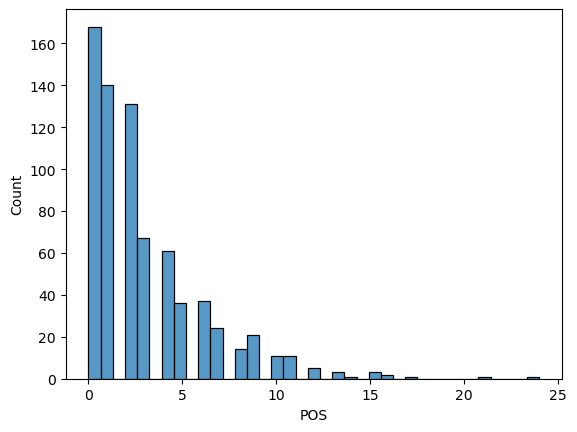

In [118]:
sns.histplot(data=df_variants_by_sample,
             x='POS'
            )

In [119]:
df_variants_by_sample.query("POS > 20")

,SampleID,POS
302,MFS-578,24
355,MFS-639,21


In [113]:
df_variants_by_sample

,SampleID,POS
0,MFS-1,1
1,MFS-100,1
2,MFS-102,6
3,MFS-105,1
4,MFS-106,5
...,...,...
129,MFS-647,0
130,MFS-419,0
131,MFS-136,0
132,MFS-629,0


In [99]:
df_trust_patients.query("SampleID in ['MFS-578', 'MFS-639']")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,duration_of_use_meth,duration_of_use_mandrax,lca,fib4,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Sampling_Week
341,T0116,S0116-06,MFS-578,MFS-578_lib65684,NaN,NaN,1.0,263.12,0.99,0.9885,...,11.0,13.0,2.0,0.209650,2.0,0.009592,2.2.1.1,2.2.1.1.1,2.0,6
399,T0210,S0210-06,MFS-639,MFS-639_lib66320,NaN,NaN,1.0,323.85,0.99,0.9856,...,8.0,8.0,2.0,0.165433,NaN,0.011633,2.2.1.1,2.2.1.1.1,2,6


In [115]:
df_unfixed_variants.query("SampleID=='MFS-639'")[['SampleID', 'POS', 'REF', 'ALT', 'SAF', 'SAR', 'AO', 'DP', 'TD', 'AF', 'Mean_BQ_ALT_allele']]#.shape

,SampleID,POS,REF,ALT,SAF,SAR,AO,DP,TD,AF,Mean_BQ_ALT_allele
2162,MFS-639,6078,G,T,25.0,15.0,39,382,384,0.102094,32.150000
2163,MFS-639,65511,G,T,12.0,6.0,17,259,260,0.065637,31.444444
2164,MFS-639,118655,C,A,8.0,10.0,16,219,221,0.073059,30.166667
2165,MFS-639,226221,G,T,15.0,14.0,26,320,320,0.081250,30.172414
2166,MFS-639,258832,C,A,14.0,13.0,23,299,299,0.076923,32.592593
2167,MFS-639,291207,C,A,9.0,5.0,14,278,281,0.050360,32.428571
2170,MFS-639,1039809,G,T,20.0,20.0,38,277,277,0.137184,32.900000
2173,MFS-639,1279930,C,A,6.0,11.0,15,267,268,0.056180,28.352941
2174,MFS-639,1457144,C,T,167.0,130.0,245,260,264,0.942308,30.555556
2175,MFS-639,1528110,C,A,10.0,7.0,13,232,234,0.056034,31.411765


(0, 4.0, 43)

In [68]:
sample = 'MFS-171'
df = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/pilon/lowAF_SNVs_aln_stats.csv")
df_confusion = pd.read_csv(f"{personal_ref_dir}/{sample}/pilon/confusion_matrix.csv")

In [70]:
df_confusion.Result.value_counts()

Result
FP    41
TP    27
Name: count, dtype: int64

In [80]:
df_confusion.query("Result=='FP'")[['H37Rv_POS', 'H37Rv_REF', 'H37Rv_ALT']].merge(df, left_on=['H37Rv_POS'], right_on='POS').shape

(41, 30)

In [83]:
df_confusion.query("Result=='FP'")[['H37Rv_POS', 'H37Rv_REF', 'H37Rv_ALT']].merge(df, left_on=['H37Rv_POS'], right_on='POS').AF.min()

0.8910891089108911

In [85]:
df.columns

Index(['CHROM', 'POS', 'REF', 'ALT', 'QUAL', 'FILTER', 'DP', 'TD', 'BQ', 'MQ',
       'BC', 'IC', 'DC', 'XC', 'AF', 'AO', 'RO', 'Mean_BQ_ALT_allele', 'SAF',
       'SAR', 'COV', 'COV_MAX_ROLLING_AVG', 'CLIPPED_BASES',
       'DISCORDANT_READS', 'COV_RATIO', 'DISCORDANT_READS_RATIO',
       'CLIPPED_BASES_RATIO'],
      dtype='object')

In [63]:
df.query("POS==410314")[['POS', 'REF', 'ALT', 'SAF', 'SAR', 'AO', 'DP', 'AF']]

,POS,REF,ALT,SAF,SAR,AO,DP,AF
4,410314,A,T,2.0,3.0,5,304,0.016447


In [37]:
df_personal = pd.read_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples_personal_genomes.csv")
len(df_personal)

179

In [153]:
df_personal.to_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples_personal_genomes.csv", index=False)

In [48]:
df_SR = pd.read_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples.tsv", sep='\t', header=None)
len(df_SR)

767

In [152]:
df_SR.to_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples.tsv", index=False, sep='\t', header=None)

# How many False SNVs are detected per sample?

In [11]:
confusion_matrix_files = glob.glob(f"{personal_ref_dir}/*/pilon/confusion_matrix.csv")
print(len(confusion_matrix_files))
df_confusion_matrix = []

for fName in confusion_matrix_files:

    df = pd.read_csv(fName)
    df['SampleID'] = os.path.basename(os.path.dirname(os.path.dirname(fName)))
    df_confusion_matrix.append(df)
    
df_confusion_matrix = pd.concat(df_confusion_matrix)

df_confusion_matrix = df_confusion_matrix.merge(df_trust_patients[['SampleID', 'F2', 'Coll2014']])

df_confusion_matrix['Region'] = df_confusion_matrix['POS'].map(h37Rv_coords_dict)

179


In [12]:
df_confusion_matrix.Result.value_counts()

Result
TP    7850
FP     728
FN      56
Name: count, dtype: int64

In [156]:
df_confusion_matrix.query("Result=='FN' & F2 <= 0.03").sort_values(['SampleID', 'POS'])

,POS,REF,ALT,H37Rv_POS,H37Rv_REF,H37Rv_ALT,Result,SampleID,F2,Coll2014,Region
24,454568.0,A,T,NaN,NaN,NaN,FN,MFS-113,0.009842,2.2.1.1,Rv0377
107,1899383.0,T,C,NaN,NaN,NaN,FN,MFS-132,0.010359,2.2.1.1,Rv1674c
182,216020.0,T,A,NaN,NaN,NaN,FN,MFS-16,0.010009,2.2.1,Rv0185
333,851061.0,C,G,NaN,NaN,NaN,FN,MFS-264,0.013014,2.2.1.1,Rv0756c
411,467579.0,G,A,NaN,NaN,NaN,FN,MFS-307,0.009584,4.1.1.1,PPE9
419,3736401.0,C,G,NaN,NaN,NaN,FN,MFS-307,0.009584,4.1.1.1,PPE54
2780,3959484.0,T,A,NaN,NaN,NaN,FN,MFS-318,0.012310,2.2.1.1,ltp4
2799,4180002.0,G,C,NaN,NaN,NaN,FN,MFS-320,0.012366,2.2.1.1,Rv3729
2866,356582.0,A,T,NaN,NaN,NaN,FN,MFS-328,0.012589,4.3.2.1,eccE3
4879,981608.0,G,T,NaN,NaN,NaN,FN,MFS-414,0.010344,2.2.1.1,serC


In [157]:
for i, row in df_confusion_matrix.query("Result=='FN' & F2 <= 0.03").iterrows():
    
    ground_truth = pd.read_csv(f"{personal_ref_dir}/{row['SampleID']}/pilon/ground_truth.csv")
    
    pos = row['POS']
    print(row['SampleID'], ground_truth.query("POS==@pos").AF.values[0])

MFS-113 0.0548780487804878
MFS-132 0.0483383685800604
MFS-16 0.0454545454545454
MFS-264 0.0649350649350649
MFS-307 0.0473684210526315
MFS-307 0.0728476821192053
MFS-318 0.0452261306532663
MFS-320 0.0628930817610062
MFS-328 0.0486486486486486
MFS-414 0.0477941176470588
MFS-58 0.0454545454545454
MFS-611 0.048076923076923
MFS-7 0.0453074433656957


In [9]:
def compute_mean_base_quality_strand_support_of_variant(bam_file, pos, low_freq_allele, chrom='Chromosome'):
    
    bam = pysam.AlignmentFile(bam_file, "rb")
    
    base_qualities_low_freq_allele = []
    reverse_reads = []

    # default min_base_quality is 13, so bad reads get excluded, which negates the purpose of this function...rolls eyes. min_mapping_quality default is 0
    for pileupcolumn in bam.pileup(chrom, pos-1, pos, truncate=True, min_base_quality=0):

        for pileupread in pileupcolumn.pileups:
            if pileupread.is_del or pileupread.is_refskip:
                continue  # skip deletions and skipped regions

            base = pileupread.alignment.query_sequence[pileupread.query_position]
            qual = pileupread.alignment.query_qualities[pileupread.query_position]

            # include only properly paired reads when computing strand bias and base quality
            if base == low_freq_allele and pileupread.alignment.is_paired and not pileupread.alignment.is_proper_pair:
                base_qualities_low_freq_allele.append(qual)
                reverse_reads.append(int(pileupread.alignment.is_reverse))
                
    # no reads passed
    if len(base_qualities_low_freq_allele) == 0:
        return 0, 0, 0
    else:
        reverse_reads = np.unique(reverse_reads, return_counts=True)
        reverse_reads = dict(zip(reverse_reads[0], reverse_reads[1]))

        if 0 in reverse_reads.keys():
            SAR = reverse_reads[0]
        else:
            SAR = 0

        if 1 in reverse_reads.keys():
            SAF = reverse_reads[1]
        else:
            SAF = 0

        return np.mean(base_qualities_low_freq_allele), SAF, SAR

In [142]:
def filter_high_quality_lowAF_variants(vcf_file, bam_file, depth_file):

    # VCF file
    df_variants = read_pilon_vcf(vcf_file)
    
    int_cols = ['DP', 'IC', 'DC', 'BQ', 'MQ', 'TD']

    for col in int_cols:
        df_variants[col] = df_variants[col].astype(int)

    # create ALT column for the variants below pilon's detection filters. Make AO = alternative count and RO = ref count (like the freebayes fields)
    df_variants[['ALT', 'AO', 'RO']] = df_variants.apply(lambda row: get_alt_allele(row["BC"], row["REF"]), axis=1, result_type="expand")

    # recompute new AF
    df_variants['AF'] = df_variants['AO'] / df_variants['DP']
        
    # apply QC filters
    df_lowAF_variants = apply_pilon_lowAF_QCfilters(df_variants).reset_index(drop=True)
    
    chrom = df_lowAF_variants.CHROM.unique()[0]
    bam = pysam.AlignmentFile(bam_file, "rb")
        
    # the base quality (BQ) column in pilon is the average BQ of all reads at the site. Need BQ of reads that support the variant
    for i, row in df_lowAF_variants.iterrows():
        mean_base_qual, SAF, SAR = compute_mean_base_quality_strand_support_of_variant(bam, row['POS'], row['ALT'], chrom=chrom)
        df_lowAF_variants.loc[i, ['Mean_BQ_ALT_allele', 'SAF', 'SAR']] = [mean_base_qual, SAF, SAR]
        
    assert sum(pd.isnull(df_lowAF_variants['Mean_BQ_ALT_allele'])) == 0
    
    # require at least 2 forward and 2 reverse reads for each variant
    # df_lowAF_variants = df_lowAF_variants.query("Mean_BQ_ALT_allele >= 20 & SAF >= 2 & SAR >= 2")

    # require that all low-AF variants occur in areas where the depth is at least half the median depth
    df_depth = pd.read_csv(depth_file, compression='gzip', header=None, sep='\t', names=['CHROM','POS', 'DEPTH'])

    depth_min = df_depth['DEPTH'].median() / 2
    print(depth_min)
    # depth_max = df_depth['DEPTH'].median() * 2

    # df_lowAF_variants = df_lowAF_variants.query("DP >= @depth_min")
    
    save_cols = ['DP', 'TD', 'BQ', 'MQ', 'BC', 'IC', 'DC', 'XC', 'AF', 'AO', 'RO', 'Mean_BQ_ALT_allele', 'SAF', 'SAR']
    
    return df_lowAF_variants[['CHROM', 'POS', 'REF', 'ALT', 'QUAL', 'FILTER'] + save_cols]

In [143]:
sample = 'MFS-307'

vcf_file = f"{H37Rv_ref_dir}/{sample}/pilon/{sample}_SNPs.excludeLowConf.vcf"
bam_file = f"{H37Rv_ref_dir}/{sample}/bam/{sample}.dedup.bam"
depth_file = f"{H37Rv_ref_dir}/{sample}/bam/{sample}.depth.tsv.gz"


df_lowAF = filter_high_quality_lowAF_variants(vcf_file,
                               bam_file,
                               depth_file,
                              )

145.0


In [145]:
df_lowAF.query("POS==467579")

,CHROM,POS,REF,ALT,QUAL,FILTER,DP,TD,BQ,MQ,BC,IC,DC,XC,AF,AO,RO,Mean_BQ_ALT_allele,SAF,SAR
1065,Chromosome,467579,G,A,3285.0,PASS,129,131,32,58,"8,0,121,0",0,0,0,0.062016,8,121,29.6,6.0,4.0


In [137]:
for i, row in df_confusion_matrix.query("Result=='FN' & F2 <= 0.03").iterrows():
    
    sample = row['SampleID']
    pos = int(row['POS'])
    alt = row['ALT']
    
    VCF_file = f"{H37Rv_ref_dir}/{sample}/pilon/{sample}_SNPs.excludeLowConf.vcf"
    bam_file = f"{H37Rv_ref_dir}/{sample}/bam/{sample}.dedup.bam"
    depth_file = f"{H37Rv_ref_dir}/{sample}/bam/{sample}.depth.tsv.gz"

    # VCF file
    df_variants = read_pilon_vcf(VCF_file)

    int_cols = ['DP', 'IC', 'DC', 'BQ', 'MQ', 'TD']

    for col in int_cols:
        df_variants[col] = df_variants[col].astype(int)

    # create ALT column for the variants below pilon's detection filters. Make AO = alternative count and RO = ref count (like the freebayes fields)
    df_variants[['ALT', 'AO', 'RO']] = df_variants.apply(lambda row: get_alt_allele(row["BC"], row["REF"]), axis=1, result_type="expand")

    # recompute new AF
    df_variants['AF'] = df_variants['AO'] / df_variants['DP']
    df_variants['AF']

    # apply QC filters
    df_lowAF_variants = apply_pilon_lowAF_QCfilters(df_variants, AF_min=0.01, AF_max=0.95, MQ_thresh=40, num_support=5).reset_index(drop=True)

    bam = pysam.AlignmentFile(bam_file, "rb")
    mean_base_qual, SAF, SAR = compute_mean_base_quality_strand_support_of_variant(bam, pos, alt, chrom=df_lowAF_variants.CHROM.unique()[0])
        
    # require that all low-AF variants occur in areas where the depth is at least half the median depth
    df_depth = pd.read_csv(depth_file, compression='gzip', header=None, sep='\t', names=['CHROM','POS', 'DEPTH'])

    depth_min = df_depth['DEPTH'].median() / 2
    # depth_max = df_depth['DEPTH'].median() * 2

    # need to use total depth (TD), not DP, for pilon which is the depth of valid reads (concordantly paired and not soft-clipped)
    # df_lowAF_variants = df_lowAF_variants.query("TD >= @depth_min")
    
    print(sample, pos, mean_base_qual, SAF, SAR, df_variants.query("POS==@pos").AF.values[0], len(df_lowAF_variants.query("TD >= @depth_min & POS==@pos")))

MFS-264 851061 21.0 1 9 0.07142857142857142 1
MFS-307 467579 29.6 6 4 0.06201550387596899 0
MFS-307 3736401 19.7 3 7 0.06666666666666667 1
MFS-320 4180002 18.444444444444443 3 6 0.05806451612903226 1
MFS-326 2784157 21.818181818181817 1 10 0.043668122270742356 1
MFS-328 356582 20.25 7 1 0.03825136612021858 1
MFS-359 746015 20.0 7 4 0.05732484076433121 1


In [140]:
sample = 'MFS-395'
pos = 3538227

confusion_matrix = pd.read_csv(f"{personal_ref_dir}/{sample}/pilon/confusion_matrix.csv")
ground_truth = pd.read_csv(f"{personal_ref_dir}/{sample}/pilon/ground_truth.csv")
H37Rv_detected = pd.read_csv(f"{personal_ref_dir}/{sample}/pilon/H37Rv_detected.csv")

H37Rv_lowAF = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/pilon/lowAF_variants.csv")

In [139]:
ground_truth.query("POS==@pos")

,POS,REF,ALT,QUAL,FILTER,DP,TD,BQ,MQ,BC,IC,DC,XC,AF
3,3538227,T,C,5724.0,PASS,268,271,29,60,"2,16,0,250",0,0,0,0.059701


In [141]:
H37Rv_lowAF.query("POS==@pos")

,CHROM,POS,REF,ALT,QUAL,FILTER,DP,TD,BQ,MQ,BC,IC,DC,XC,AF,AO,RO


In [175]:
for sample in samples_lst:
    os.remove(f"{personal_ref_dir}/{sample}/pilon/confusion_matrix.csv")

In [156]:
sample = 'MFS-395'
VCF_file = f"{H37Rv_ref_dir}/{sample}/pilon/{sample}_SNPs.excludeLowConf.vcf"
bam_file = f"{H37Rv_ref_dir}/{sample}/bam/{sample}.dedup.bam"
depth_file = f"{H37Rv_ref_dir}/{sample}/bam/{sample}.depth.tsv.gz"

df_lowAF = filter_high_quality_lowAF_variants(VCF_file, 
                                              bam_file, 
                                              depth_file
                                             )

1
1
           CHROM      POS REF    QUAL FILTER   DP   TD  BQ  MQ          BC  \
2189  Chromosome  3538227   C  5665.0   PASS  269  275  30  60  2,17,0,250   

      IC  DC XC ALT   AO  RO        AF  Mean_BQ_ALT_allele    SAF    SAR  
2189   0   0  2   T  250  17  0.929368           29.835766  135.0  139.0  
0
0


In [ ]:
# require that all low-AF variants occur in areas where the depth is at least half the median depth
df_depth = pd.read_csv(depth_file, compression='gzip', header=None, sep='\t', names=['CHROM','POS', 'DEPTH'])

depth_min = df_depth['DEPTH'].median() / 2
# depth_max = df_depth['DEPTH'].median() * 2

# need to use total depth (TD), not DP, for pilon which is the depth of valid reads (concordantly paired and not soft-clipped)
df_lowAF_variants = df_lowAF_variants.query("TD >= @depth_min")

In [53]:
df_lowAF = filter_high_quality_lowAF_variants(f"{H37Rv_ref_dir}/{sample}/pilon/{sample}_SNPs.excludeLowConf.vcf",
                                   f"{H37Rv_ref_dir}/{sample}/bam/{sample}.dedup.bam",
                                   f"{H37Rv_ref_dir}/{sample}/bam/{sample}.depth.tsv.gz",
                                  )

1
1
0



KeyboardInterrupt



In [51]:
df_lowAF.query("POS==@pos")

,CHROM,POS,REF,QUAL,FILTER,DP,TD,BQ,MQ,BC,IC,DC,XC,ALT,AO,RO,AF,Mean_BQ_ALT_allele


In [131]:
def read_pilon_vcf(vcf_path):
    
    # XC is the number of clipped bases at the site
    keep_cols = ['CHROM', 'POS', 'REF', 'QUAL', 'FILTER', 'DP', 'TD', 'BQ', 'MQ', 'BC', 'IC', 'DC', 'XC']

    records = []
    info_keys = set()
    format_keys = set()

    with open(vcf_path) as f:
        for line in f:
            line = line.strip()

            # Skip meta-information
            if line.startswith("##"):
                continue

            # Header line
            if line.startswith("#CHROM"):
                header = line.lstrip("#").split("\t")
                continue

            # Variant line
            fields = dict(zip(header, line.split("\t")))

            # --------------------
            # Parse INFO field
            # --------------------
            info_dict = {}
            for item in fields["INFO"].split(";"):
                if "=" in item:
                    k, v = item.split("=", 1)
                    info_dict[k] = v
                else:
                    # Flag field (e.g. IMPRECISE)
                    info_dict[item] = True

            info_keys.update(info_dict.keys())

            # --------------------
            # Parse FORMAT field(s)
            # --------------------
            format_dict = {}
            if "FORMAT" in fields:
                fmt_keys = fields["FORMAT"].split(":")
                sample_cols = [c for c in header if c not in {
                    "CHROM","POS","ID","REF","ALT","QUAL","FILTER","INFO","FORMAT"
                }]

                for sample in sample_cols:
                    fmt_vals = fields[sample].split(":")
                    for k, v in zip(fmt_keys, fmt_vals):
                        format_dict[f"{sample}_{k}"] = v
                        format_keys.add(f"{sample}_{k}")

            # --------------------
            # Combine everything
            # --------------------
            base = {
                "CHROM": fields["CHROM"],
                "POS": int(fields["POS"]),
                "REF": fields["REF"],
                "ALT": fields["ALT"],
                "QUAL": None if fields["QUAL"] == "." else float(fields["QUAL"]),
                "FILTER": fields["FILTER"],
            }

            record = {**base, **info_dict, **format_dict}
            records.append(record)

    # --------------------
    # Build DataFrame
    # --------------------
    df = pd.DataFrame(records)

    # Ensure all INFO / FORMAT columns exist even if missing in some rows
    for col in info_keys.union(format_keys):
        if col not in df.columns:
            df[col] = pd.NA

    return df[keep_cols].reset_index(drop=True)




def get_alt_allele(BC_string, ref_allele, base_order=['A', 'C', 'G', 'T']):
    '''
    Already filtered the VCF to require there to be at least 5 non-REF reads, so there will be an ALT allele
    '''
    
    alt_counts = np.array(BC_string.split(',')).astype(int)
    
    ref_idx = base_order.index(ref_allele)
    ref_count = alt_counts[ref_idx]
    
    # sort after set subtraction. base order is in alpha order
    non_ref_alleles = np.sort(list(set(base_order) - set([ref_allele])))
    non_ref_counts = [count for i, count in enumerate(alt_counts) if i != ref_idx]
    assert len(non_ref_counts) == len(alt_counts) - 1
    
    # if there are multiple ALT alleles with the same support, the first one in alpha-order is returned.
    alt_allele = non_ref_alleles[np.argmax(non_ref_counts)]
    
    return alt_allele, np.max(non_ref_counts), ref_count




def apply_pilon_lowAF_QCfilters(df_variants, AF_min=0.04, AF_max=0.96, MQ_thresh=40, num_support=5):
    '''
    For columns BC and QP, the order of values is A,C,G,T
    '''
        
    # some variants could have high IC or DC in mixed lineage samples. One strain may have the SNP and another may have the deletion
    # idk, we would still need to separate them before being confident in the variants
    df_variants = df_variants.query("MQ >= @MQ_thresh").query("REF.str.len() == ALT.str.len()")
    
    # AF thresholding 
    df_lowAF_variants = df_variants.query("AF >= @AF_min & AF <= @AF_max")
    
    # added after processing the output of the get_alt_allele function
    df_lowAF_variants = df_lowAF_variants.query("AO >= @num_support")
    
    return df_lowAF_variants.reset_index(drop=True)



def save_table_of_soft_clips(sample, bam_file, ref_genome_file):
    
    dir_name = os.path.dirname(bam_file)
    
    genome_length = fasta_length(ref_genome_file)
    
    bam = pysam.AlignmentFile(bam_file, "rb")
    chrom = bam.references[0]

    records = []
    for read in bam.fetch():

        # skip unmapped reads or those with secondary or supplementary alignments
        if read.is_unmapped or read.is_secondary or read.is_supplementary:
            continue
            
        num_left_clip = 0
        num_right_clip = 0

        if read.cigartuples:
            
            # check first operator
            if read.cigartuples[0][0] == 4:  # 4 = soft clip
                num_left_clip = read.cigartuples[0][1]

            # check last operator
            if read.cigartuples[-1][0] == 4:
                num_right_clip = read.cigartuples[-1][1]
                
        # add 1 because it's 0-indexed half-open
        start = read.reference_start + 1

        # don't add 1 because it's half-open at the end
        end = read.reference_end

        records.append({
            "read_name": read.query_name,
            "chrom": chrom,
            "start": start,
            "end": end,
            "cigar_string": read.cigarstring,
            "soft_clipped_bases": num_left_clip + num_right_clip, # total
            "left_clip_start": start - num_left_clip if num_left_clip > 0 else np.nan,
            "left_clip_end": start - 1 if num_left_clip > 0 else np.nan,
            "right_clip_start": end + 1 if num_right_clip > 0 else np.nan,
            "right_clip_end": end + num_right_clip if num_right_clip > 0 else np.nan,
        })

    bam.close()

    df = pd.DataFrame(records)
    
    # there will be clipping at the ends because the genome is circular, but we aligned reads to the linearized genome
    # exclude those from this computation because they're more artifactual
    # THESE ARE 1-INDEXED CLOSED INTERVALS, so the genome ranges from 1 - genome_length, INCLUSIVE
    # so exclude any soft-clipped regions that extend outside of the ref genome AT ALL
    df_soft_clips = df.dropna(subset=['left_clip_start', 'right_clip_start'], how='all').query("~(left_clip_start < 1) & ~(right_clip_end > @genome_length)").reset_index(drop=True)
    
    # convert this to a BED file, then use bedtools genomecov because we're getting a coverage track of soft clipping
    # make sure to get both left and right clips. Expand them like this
    df_soft_clips_BED = pd.concat([df_soft_clips.dropna(subset='left_clip_start')[['chrom', 'left_clip_start', 'left_clip_end']].rename(columns={'left_clip_start': 'BEG', 'left_clip_end': 'END'}),
                                   df_soft_clips.dropna(subset='right_clip_start')[['chrom', 'right_clip_start', 'right_clip_end']].rename(columns={'right_clip_start': 'BEG', 'right_clip_end': 'END'})
                                  ])

    # because we expanded, the length should be at least as long as df_soft_clips. And more than likely longer because some reads have both left and right soft clipping
    assert len(df_soft_clips_BED) >= len(df_soft_clips)
    # print(len(df_soft_clips_BED), len(df_soft_clips))

    # convert to 0-indexed half open intervals
    df_soft_clips_BED['BEG'] -= 1
    df_soft_clips_BED[['BEG', 'END']] = df_soft_clips_BED[['BEG', 'END']].astype(int)
    
    soft_clipping_BED_file = os.path.join(dir_name, f"{sample}.softClips.bed")
    df_soft_clips_BED.to_csv(soft_clipping_BED_file, sep='\t', header=None, index=False)
    
    ref_genome_chrom_lengths_file = f"{ref_genome_file.replace('.fna', '')}.chrom_lengths.txt"
    
    # then run the following to compute the number of soft clipped 
    if not os.path.isfile(ref_genome_chrom_lengths_file):
        subprocess.run(f"cut -f1,2 {ref_genome_file}.fai > {ref_genome_chrom_lengths_file}", shell=True)

    soft_clips_by_pos_file = os.path.join(dir_name, f"{sample}.softClips.tsv.gz")
    subprocess.run(f"bedtools genomecov -i {soft_clipping_BED_file} -g {ref_genome_chrom_lengths_file} -d | gzip -c > {soft_clips_by_pos_file}", shell=True)
    
    
    
    
def get_orientation(read):
    """Return orientation of the pair: LR, RL, LL, RR, or None if not valid pair."""
    if not (read.is_paired and not read.is_unmapped and not read.mate_is_unmapped):
        return None

    # different chromosomes
    if read.reference_id != read.next_reference_id:
        return "DIFF_CHR"

    mate_start = read.next_reference_start
    this_start = read.reference_start

    # Determine left and right mate
    if this_start <= mate_start:
        left_rev  = read.is_reverse
        right_rev = read.mate_is_reverse
    else:
        left_rev  = read.mate_is_reverse
        right_rev = read.is_reverse

    if not left_rev and right_rev:
        return "LR"   # forward (left) + reverse (right) = normal Illumina
    if left_rev and not right_rev:
        return "RL"   # reverse (left) + forward (right) = IGV green
    if not left_rev and not right_rev:
        return "LL"   # both forward
    if left_rev and right_rev:
        return "RR"   # both reverse
    
    
    
def save_table_of_discordant_reads(sample, bam_file, ref_genome_file):
    
    dir_name = os.path.dirname(bam_file)
    
    genome_length = fasta_length(ref_genome_file)
    
    bam = pysam.AlignmentFile(bam_file, "rb")
    chrom = bam.references[0]

    records = []
    
    for read in bam.fetch():

        # skip unmapped reads or those with secondary or supplementary alignments
        if read.is_unmapped or read.is_secondary or read.is_supplementary:
            continue

        orientation = get_orientation(read)

        if orientation != 'LR':
            
            # add 1 because it's 0-indexed half-open
            start = read.reference_start + 1

            # don't add 1 because it's half-open at the end
            end = read.reference_end
        
            records.append({
                "read_name": read.query_name,
                "chrom": chrom,
                "start": start,
                "end": end,
                "orientation": orientation,
                "insert_size": abs(read.template_length)
            })

    bam.close()

    df = pd.DataFrame(records)
    
    df_discordant_reads_BED = df[['chrom', 'start', 'end']]
    
    # convert to 0-indexed half open intervals
    df_discordant_reads_BED['start'] -= 1
    df_discordant_reads_BED[['start', 'end']] = df_discordant_reads_BED[['start', 'end']].astype(int)
    
    # save BED file
    discordant_alns_BED_file = os.path.join(dir_name, f"{sample}.DiscordantReads.bed")
    df_discordant_reads_BED.to_csv(discordant_alns_BED_file, sep='\t', header=None, index=False)
    
    # run bedtools genomecov
    ref_genome_chrom_lengths_file = f"{ref_genome_file.replace('.fna', '')}.chrom_lengths.txt"
    
    # then run the following to compute the number of soft clipped 
    if not os.path.isfile(ref_genome_chrom_lengths_file):
        subprocess.run(f"cut -f1,2 {ref_genome_file}.fai > {ref_genome_chrom_lengths_file}", shell=True)

    discordant_alns_by_pos_file = os.path.join(dir_name, f"{sample}.DiscordantReads.tsv.gz")
    subprocess.run(f"bedtools genomecov -i {discordant_alns_BED_file} -g {ref_genome_chrom_lengths_file} -d | gzip -c > {discordant_alns_by_pos_file}", shell=True)
    
    


def compute_mean_base_quality_strand_support_of_variant(bam, pos, low_freq_allele, chrom='Chromosome'):
        
    base_qualities_low_freq_allele = []
    SAF = 0
    SAR = 0

    # default min_base_quality is 13, so bad reads get excluded, which negates the purpose of this function...rolls eyes. min_mapping_quality default is 0
    for pileupcolumn in bam.pileup(chrom, pos-1, pos, truncate=True, min_base_quality=0):

        for pileupread in pileupcolumn.pileups:
            if pileupread.is_del or pileupread.is_refskip:
                continue  # skip deletions and skipped regions

            base = pileupread.alignment.query_sequence[pileupread.query_position]
            qual = pileupread.alignment.query_qualities[pileupread.query_position]

            # include only properly paired reads when computing strand bias and base quality
            if base == low_freq_allele and pileupread.alignment.is_paired and pileupread.alignment.is_proper_pair:
                base_qualities_low_freq_allele.append(qual)
                
                if pileupread.alignment.is_reverse:
                    SAR += 1
                else:
                    SAF += 1
                
    # no reads passed
    if len(base_qualities_low_freq_allele) == 0:
        return 0, SAF, SAR
    else:
        return np.mean(base_qualities_low_freq_allele), SAF, SAR

In [22]:
df_confusion_matrix.query("SampleID in ['MFS-325', 'MFS-326']").sort_values('POS')

,POS,REF,ALT,H37Rv_POS,H37Rv_REF,H37Rv_ALT,Result,SampleID,F2,Coll2014,Region
2598,13629.0,A,G,13629.0,A,G,TP,MFS-325,0.011467,2.2.1.1,NC_9
2608,13629.0,A,G,13629.0,A,G,TP,MFS-326,0.013818,2.2.1.1,NC_9
2599,852970.0,C,A,852970.0,C,A,TP,MFS-325,0.011467,2.2.1.1,phoR
2609,852970.0,C,A,852970.0,C,A,TP,MFS-326,0.013818,2.2.1.1,phoR
2600,1699255.0,T,C,NaN,NaN,NaN,FN,MFS-325,0.011467,2.2.1.1,Rv1508c
2610,1699255.0,T,C,NaN,NaN,NaN,FN,MFS-326,0.013818,2.2.1.1,Rv1508c
2601,2109016.0,T,C,2109016.0,T,C,TP,MFS-325,0.011467,2.2.1.1,NC_1447
2611,2109016.0,T,C,2109016.0,T,C,TP,MFS-326,0.013818,2.2.1.1,NC_1447
2612,2207601.0,T,C,2207601.0,T,C,TP,MFS-326,0.013818,2.2.1.1,NC_1529
2603,2697452.0,A,G,2697452.0,A,G,TP,MFS-325,0.011467,2.2.1.1,subI


In [11]:
df_lowAF_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF/MFS-1/pilon/lowAF_variants_aln_stats.csv")

In [16]:
df_lowAF_variants[['CHROM', 'POS', 'REF', 'ALT', 'DP', 'BQ', 'MQ', 'XC', 'AO', 'RO', 'AF', 'COV', 'COV_MAX_ROLLING_AVG', 'CLIPPED_BASES', 'DISCORDANT_READS', 'COV_RATIO',
       'DISCORDANT_READS_RATIO', 'CLIPPED_BASES_RATIO']]

,CHROM,POS,REF,ALT,DP,BQ,MQ,XC,AO,RO,AF,COV,COV_MAX_ROLLING_AVG,CLIPPED_BASES,DISCORDANT_READS,COV_RATIO,DISCORDANT_READS_RATIO,CLIPPED_BASES_RATIO
0,Chromosome,2076862,A,G,260,34,60,0,22,238,0.084615,273,282.25,1,5,0.967228,0.018315,0.003663
1,Chromosome,2591484,G,A,412,31,59,0,285,118,0.691748,608,635.78,5,140,0.956306,0.230263,0.008224
2,Chromosome,2592310,G,A,369,33,56,0,251,117,0.680217,530,593.36,1,117,0.893218,0.220755,0.001887
